# ChemNet Projections for Encoder 1234e1e2 weighted

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

def plot_chemnet_pca(bin_val=1, threshold_val=0.1, 
                     include_super_test=True, include_regular_test=True, 
                     include_true_chemnet=True, include_training=True,
                     color_by_smiles=True, figsize=(12, 8), max_spectra_per_chemical=10, max_smiles_per_set=100):
    """
    Plot 2D PCA projections of chemnet embeddings with appropriate markers for dataset types
    
    Parameters:
    - bin_val, threshold_val: Parameters to select specific model outputs
    - include_super_test: Include super test chemicals (circles)
    - include_regular_test: Include regular test chemicals (squares)
    - include_true_chemnet: Include true ChemNet embeddings (x markers)
    - include_training: Include training spectra (triangles)
    - color_by_smiles: Color points by SMILES strings, but do not include in legend
    - figsize: Figure size tuple
    - max_spectra_per_chemical: Maximum number of spectra to plot per SMILES
    - max_smiles_per_set: Maximum number of SMILES to include per dataset type
    """
    
    base_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data"
    bin_part = str(bin_val).replace('.', '_')
    threshold_part = str(threshold_val).replace('.', '_')

    # Initialize lists to store all data
    all_embeddings = []
    all_smiles = []
    all_dataset_types = []
    all_markers = []
    
    embedding_dim = None
    selected_smiles = set()  # Track selected SMILES across all datasets

    def pad_or_truncate(embeddings, target_dim):
        if embeddings.shape[1] < target_dim:
            return np.hstack([embeddings, np.zeros((embeddings.shape[0], target_dim - embeddings.shape[1]))])
        elif embeddings.shape[1] > target_dim:
            return embeddings[:, :target_dim]
        return embeddings

    def sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles):
        """Limit the number of spectra per SMILES."""
        selected_rows = []
        for smile in df[smiles_col].unique():
            smile_rows = df[df[smiles_col] == smile]
            if len(smile_rows) > max_per_smiles:
                selected_rows.extend(smile_rows.sample(max_per_smiles).index)
            else:
                selected_rows.extend(smile_rows.index)
        return df.loc[selected_rows]

    def sample_smiles(df, smiles_col, max_smiles, embedding_cols, max_per_smiles):
        """Limit the number of unique SMILES and apply spectra size restriction."""
        unique_smiles = pd.unique(df[smiles_col])
        if len(unique_smiles) > max_smiles:
            selected_smiles_subset = np.random.choice(unique_smiles, max_smiles, replace=False)
            df = df[df[smiles_col].isin(selected_smiles_subset)]
        
        return sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_per_smiles)

    def load_and_process_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra", track_smiles=False):
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            
            embedding_cols = [col for col in df.columns if col.startswith('cond_emb_') 
                              and 'morgan' not in col.lower() and 'filtered' not in col.lower()]
            
            df = sample_smiles(df, smiles_col, max_smiles_per_set, embedding_cols, max_spectra_per_chemical)
            
            if not embedding_cols:
                return
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values

            if track_smiles:
                selected_smiles.update(smiles)  # Add SMILES from this dataset to the shared set
            
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
            print(f"Loaded {len(smiles)} samples for {dataset_label}.")

        except FileNotFoundError:
            print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")

    def load_and_process_chemnet_data(file_path, dataset_label, marker, smiles_col="SMILES_spectra"):
        """Process ChemNet embeddings restricted to previously selected SMILES."""
        nonlocal embedding_dim, selected_smiles
        try:
            df = pd.read_parquet(file_path)
            
            embedding_cols = [col for col in df.columns if col.startswith('Embedding Float ')]
            embedding_cols.sort(key=lambda x: int(x.split()[-1]))
            
            # Restrict to SMILES selected from other datasets
            df = df[df[smiles_col].isin(selected_smiles)]
            df = sample_spectra_per_chemical(df, smiles_col, embedding_cols, max_spectra_per_chemical)
            
            if not embedding_cols:
                return
            
            embeddings = df[embedding_cols].values
            smiles = df[smiles_col].values
            
            if embedding_dim is None:
                embedding_dim = embeddings.shape[1]
            
            embeddings = pad_or_truncate(embeddings, embedding_dim)
            
            all_embeddings.extend(embeddings)
            all_smiles.extend(smiles)
            all_dataset_types.extend([dataset_label] * len(smiles))
            all_markers.extend([marker] * len(smiles))
            print(f"Loaded {len(smiles)} samples for {dataset_label}.")

        except FileNotFoundError:
            print(f"File not found: {file_path}")
        except Exception as e:
            print(f"Error processing {dataset_label}: {e}")

    # Load datasets in sequence
    if include_regular_test:
        regular_file = f"{base_folder}/cond_enc_1234e1e2_outputs_df6/cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        load_and_process_data(regular_file, "Regular Test", 's', track_smiles=True)
    
    if include_super_test:
        super_file = f"{base_folder}/cond_enc_1234e1e2_supertest_outputs/super_test_cond_enc_bin{bin_part}_thresh{threshold_part}_df_spectra.parquet"
        load_and_process_data(super_file, "Super Test", 'o', track_smiles=True)
    
    if include_training:
        training_file = f"{base_folder}/df6_spectra.parquet"
        load_and_process_data(training_file, "Training", '^', track_smiles=True)
    
    if include_true_chemnet:
        chemnet_file = f"{base_folder}/df6_chemnet.parquet"
        load_and_process_chemnet_data(chemnet_file, "True ChemNet", 'x')

    if not all_embeddings:
        print("No data loaded! Please verify file paths.")
        return
    
    embeddings_matrix = np.array(all_embeddings)
    smiles_array = np.array(all_smiles)
    dataset_types_array = np.array(all_dataset_types)
    markers_array = np.array(all_markers)

    print(f"Total samples loaded: {len(embeddings_matrix)}")
    
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_matrix)
    
    pca = PCA(n_components=2, random_state=42)
    embeddings_2d = pca.fit_transform(embeddings_scaled)
    print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")

    if color_by_smiles:
        unique_smiles = list(set(smiles_array))
        colors = plt.cm.tab20(np.linspace(0, 1, len(unique_smiles)))
        smiles_to_color = {smile: color for smile, color in zip(unique_smiles, colors)}
        point_colors = np.array([smiles_to_color[smiles] for smiles in smiles_array])
    else:
        point_colors = 'black'

    fig, ax = plt.subplots(figsize=figsize)

    for dataset_type in set(dataset_types_array):
        mask = dataset_types_array == dataset_type
        marker = markers_array[mask][0]
        subset_colors = point_colors[mask] if color_by_smiles else 'black'
        
        specific_alpha = 1.0 if dataset_type == "True ChemNet" else 0.7
        
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=subset_colors,
            marker=marker,
            s=50,
            alpha=specific_alpha,
            label=dataset_type
        )

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f} variance explained)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f} variance explained)')
    ax.set_title(f'2D PCA of ChemNet Embeddings\n(bin={bin_val}, threshold={threshold_val})')

    marker_map = {
        'Regular Test': 's',
        'Super Test': 'o',
        'True ChemNet': 'x',
        'Training': '^'
    }
    legend_elements = [
        Line2D([0], [0], marker=marker_map[label], color='w', markersize=8, markeredgecolor='black',
               label=label, markerfacecolor='black')  # Both marker shape and label
        for label in marker_map if label in set(dataset_types_array)
    ]
    ax.legend(handles=legend_elements, title='Dataset Types', bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

Loaded 35 samples for Regular Test.
Loaded 40 samples for Super Test.
Loaded 10 samples for True ChemNet.
Total samples loaded: 85
PCA explained variance ratio: [0.1798448 0.1356305]


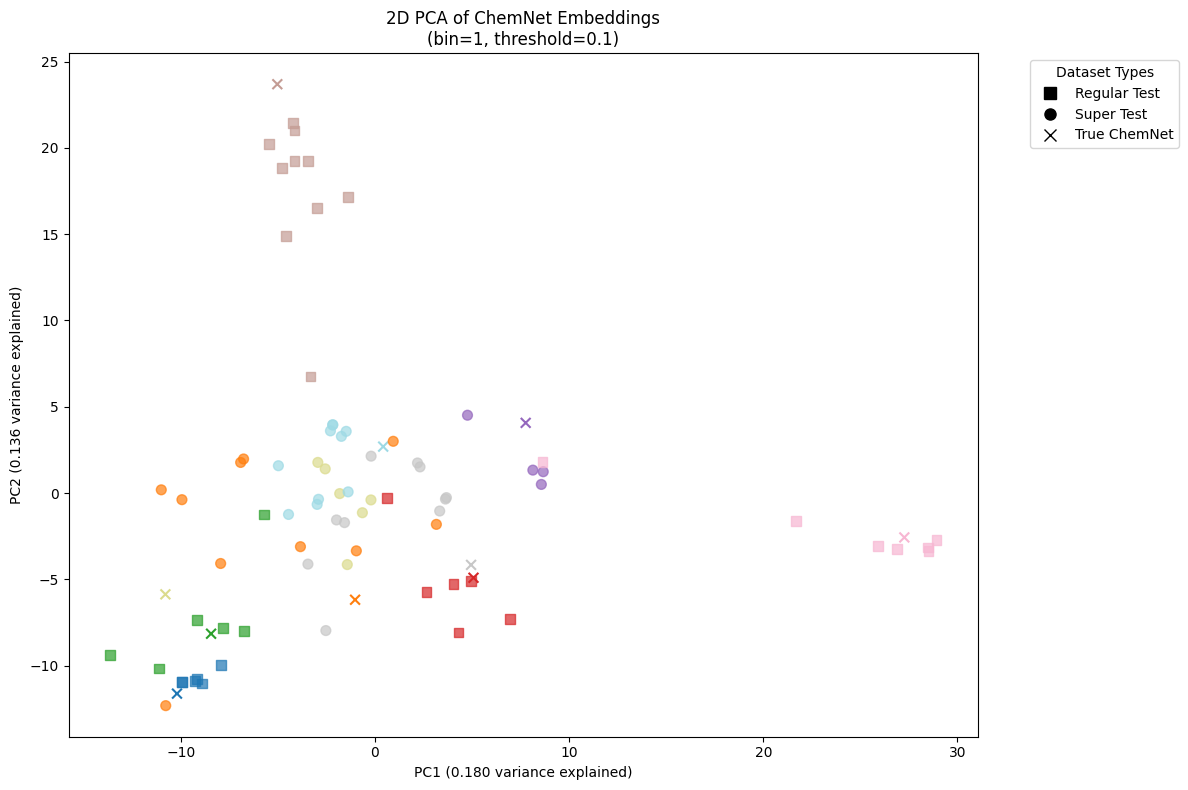

In [8]:
plot_chemnet_pca(
    bin_val=1,                              # The bin value used for naming outputs (default: 1)
    threshold_val=0.1,                      # The threshold value for naming outputs (default: 0.1)
    include_super_test=True,                # Whether to include super test dataset (default: True)
    include_regular_test=True,              # Whether to include regular test dataset (default: True)
    include_true_chemnet=True,              # Whether to include True ChemNet embeddings (default: True)
    include_training=True,                  # Whether to include training dataset (default: True)
    color_by_smiles=True,                   # Whether to color points by SMILES (default: True)
    figsize=(12, 8),                        # Size of the figure (default: (12, 8))
    max_spectra_per_chemical=10,            # Maximum spectra per chemical plotted (default: 10)
    max_smiles_per_set=5                  # Maximum number of SMILES per dataset (default: 100)
)

# ChemNet Projections for Encoder 1234e1e2 classification